# Chapter 3 — neural CDEs, worked examples from scratch

Companion to **Chapter 3 of Patrick Kidger's _On Neural Differential Equations_**, pp. 49–72. This follows the explanation → runnable code → plot/check → **what to notice** format of your chapter 2 notebook.

**One idea:** a neural CDE keeps a memory $y$ and learns how changes in the input path $X$ should update it:
$$y(0)=\zeta_\theta(X(0)),\qquad dy=f_\theta(y)\,dX,\qquad \widehat o=\ell_\theta(y(T)).$$

| Notebook example | Book section | What you will see |
|---|---|---|
| 1. Signal and its integral | Example 3.2 | A two-component state copies a signal and integrates it |
| 2. Time and sequence length | Example 3.8 | A constant signal needs a time channel |
| 3. Spiral classification | 3.1.4.1 and Appendix D.3 | Train an eight-state neural CDE on clean and noisy spirals |
| 4. Irregular and missing observations | 3.2.1, 3.2.1.4 | Uneven times, per-feature counts, rectilinear updates |
| 5. CDEs, RNNs and GRUs | 3.2.2, Example 3.14 | Verify the Euler identities numerically |
| 6. Long sequences / log-ODE idea | 3.2.3 | Large blocks need within-block order information |
| 7. CDE discriminator for SDE paths | 3.2.4 | A small adversarial training example |
| 8. Expressive hidden features | 3.3.1 | A linear readout combines nonlinear path features |
| 9. Copying paths vs input-value ODEs | 3.3.2 | Exact copying and the missing-slope problem |
| 10. Two invariances | 3.3.3 | Starting levels and real timestamps matter |
| 11. Gates and response-matrix cost | 3.4.1–3.4.2 | Bounded responses and parameter counts |
| 12. Stacked CDEs | 3.4.3 | Solve two layers together |
| 13. Interpolation and future information | 3.5 | Compare four schemes and check causality |

**Scope:** The numbered examples (3.2, 3.8, 3.14) are implemented directly. The spiral experiment uses the book's spiral equation and eight-dimensional hidden state, but a smaller CPU-friendly training setup. Sections without a worked experiment receive clearly labelled teaching demonstrations; these are not proofs or benchmark reproductions. Section 3.6 contains historical comments rather than another experiment.

**Run top to bottom.** Choose `/Users/pasha/Desktop/master/master_thesis/sandbox/.venv/bin/python` as the kernel. All data are synthetic, seeded and generated here; no downloads. Dependencies: `jax`, `diffrax`, `optax`, `numpy`, `scipy`, `matplotlib`, `ipykernel`. First-time JAX compilation can dominate runtime. Outputs are saved so you can also read without rerunning.

In [1]:
from typing import Callable, Any
import time
import jax
import jax.numpy as jnp
import jax.random as jr
import diffrax as dfx
import optax
import numpy as np
from scipy.interpolate import CubicSpline, CubicHermiteSpline
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (7, 3), "axes.grid": True, "grid.alpha": 0.2})
print("JAX", jax.__version__, "Diffrax", dfx.__version__, "device", jax.devices()[0])


def fit(params: Any, loss_fn: Callable, steps: int = 100,
        lr: float = 0.02) -> tuple[Any, np.ndarray]:
    """Train a parameter PyTree with Adam; return parameters and loss history."""
    optimizer = optax.adam(lr)
    state = optimizer.init(params)

    @jax.jit
    def step(p: Any, s: Any) -> tuple[Any, Any, jax.Array]:
        value, grad = jax.value_and_grad(loss_fn)(p)
        updates, s = optimizer.update(grad, s, p)
        return optax.apply_updates(p, updates), s, value

    history = []
    for _ in range(steps):
        params, state, value = step(params, state)
        history.append(float(value))
    return params, np.asarray(history)


def init_mlp(key: jax.Array, in_size: int, width: int,
             out_size: int, scale: float = 0.15) -> dict:
    """Initialize a one-hidden-layer MLP with fan-in-scaled weights."""
    k1, k2 = jr.split(key)
    return {"w1": jr.normal(k1, (width, in_size)) * scale / np.sqrt(in_size),
            "b1": jnp.zeros(width),
            "w2": jr.normal(k2, (out_size, width)) * scale / np.sqrt(width),
            "b2": jnp.zeros(out_size)}


def mlp(params: dict, x: jax.Array) -> jax.Array:
    """Map one vector through a smooth feedforward network."""
    return params["w2"] @ jax.nn.softplus(params["w1"] @ x + params["b1"]) + params["b2"]


def analytic_cde(path: Callable, response: Callable, y0: np.ndarray,
                 grid: np.ndarray) -> np.ndarray:
    """Solve dy/dt = response(y) @ path'(t) for a smooth analytic path."""
    sol = solve_ivp(lambda t, y: response(y) @ path(t),
                    (float(grid[0]), float(grid[-1])), y0, t_eval=grid,
                    rtol=1e-9, atol=1e-11)
    if not sol.success:
        raise RuntimeError(sol.message)
    return sol.y.T

JAX 0.6.2 Diffrax 0.7.0 device TFRT_CPU_0


## 1. Example 3.2: copy a signal and calculate its integral

Drive the state by $X(t)=(t,x(t))$. Choose
$$f(y)=\begin{bmatrix}0&1\\y_1&0\end{bmatrix},\qquad y(0)=(x(0),0).$$
Multiplying gives $dy_1=dx$ and $dy_2=y_1dt$. Therefore $y_1(t)=x(t)$ and $y_2(t)=\int_0^t x(s)ds$.

**Math → code:** `signal_response` is the matrix $f$; `derivative` supplies $X'(t)$. We check both the book's sine example and a shifted quadratic to show that the initial value matters.

sine maximum error: 1.83e-09
2 + t² maximum error: 7.11e-14


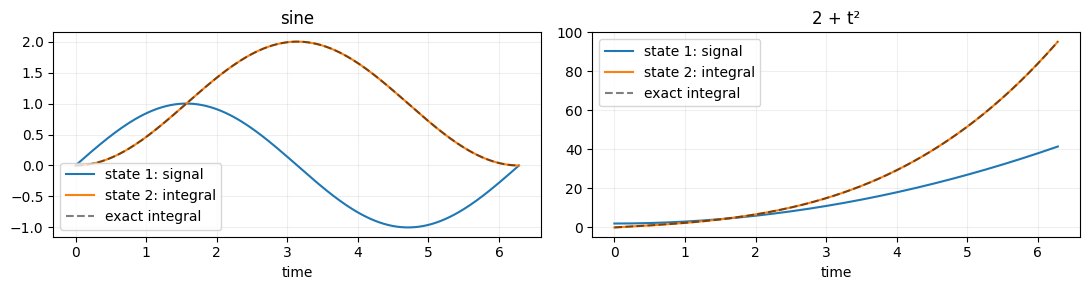

In [2]:
def signal_response(y: np.ndarray) -> np.ndarray:
    """Return the book's two-by-two response matrix."""
    return np.array([[0.0, 1.0], [y[0], 0.0]])

signal_grid = np.linspace(0, 2 * np.pi, 201)
signal_cases = [
    ("sine", lambda t: np.sin(t), lambda t: np.cos(t), lambda t: 1-np.cos(t)),
    ("2 + t²", lambda t: 2+t*t, lambda t: 2*t, lambda t: 2*t+t**3/3),
]
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
for ax, (name, signal, slope, integral) in zip(axes, signal_cases):
    derivative = lambda t: np.array([1.0, slope(t)])
    hidden = analytic_cde(derivative, signal_response,
                          np.array([signal(0), 0.0]), signal_grid)
    truth = np.column_stack([signal(signal_grid), integral(signal_grid)])
    error = np.max(np.abs(hidden-truth))
    assert error < 1e-6
    print(name, "maximum error:", f"{error:.2e}")
    ax.plot(signal_grid, hidden[:, 0], label="state 1: signal")
    ax.plot(signal_grid, hidden[:, 1], label="state 2: integral")
    ax.plot(signal_grid, truth[:, 1], "--", color="black", alpha=0.5, label="exact integral")
    ax.set(title=name, xlabel="time")
    ax.legend()
plt.tight_layout()
plt.show()

**What to notice:** The state is doing two different computations at once. The time column allows accumulation even when the signal itself is momentarily flat. There is no learning here: we deliberately choose a response matrix with a known answer.

## 2. Example 3.8: why time must be a channel

For a constant measurement, $dx=0$. Without time, the hidden state cannot tell a short constant sequence from a long one. With $X=(t,x)$, choosing $f=[1,0]$ gives $dy=dt$ and $y(n)=n$.

$n$ is elapsed index time / number of intervals. The sequence $x_0,\ldots,x_n$ has $n+1$ observations, so add one to report the observation count.

Intervals: [ 2  5 10 20]
Final state without time: [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]
Final state with time: [np.float64(2.0), np.float64(5.0), np.float64(10.0), np.float64(20.0)]


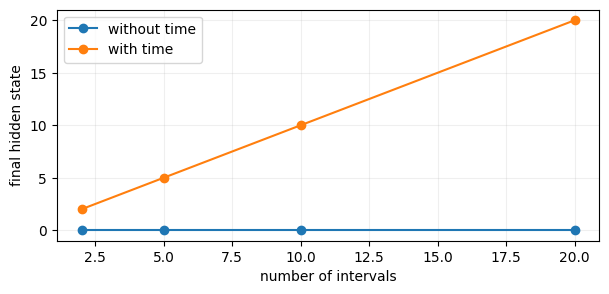

In [3]:
lengths = np.array([2, 5, 10, 20])
without_time, with_time = [], []
for n in lengths:
    grid = np.arange(n + 1, dtype=float)
    values = np.full(n + 1, 5.0)
    without_time.append(np.sum(np.diff(values)))
    control = np.column_stack([grid, values])
    with_time.append(np.sum(np.diff(control, axis=0) @ np.array([1.0, 0.0])))
assert np.allclose(with_time, lengths)
print("Intervals:", lengths)
print("Final state without time:", without_time)
print("Final state with time:", with_time)
plt.plot(lengths, without_time, "o-", label="without time")
plt.plot(lengths, with_time, "o-", label="with time")
plt.xlabel("number of intervals")
plt.ylabel("final hidden state")
plt.legend()
plt.show()

## 3. Spiral classification: train a real neural CDE

The book's spiral equation is a contracting rotation. We generate it analytically as
$$a(t)=e^{-0.3t}\cos(\alpha+\omega t),\quad b(t)=e^{-0.3t}\sin(\alpha+\omega t),\quad \omega\in\{-2,+2\}.$$
This is equivalent to the book's rotation matrix and reflection construction. Label 1 means anticlockwise; label 0 means clockwise.

The control is $X=(t,a,b)$, memory size is 8, and the learned output matrix has shape **8 × 3**. Train a separate model for clean and Gaussian-noisy observations. Use independent test spirals, not training accuracy alone.

**CPU-friendly difference from Appendix D.3:** smaller networks/data; piecewise-linear controls with two Heun substeps per interval; full-batch Adam. The continuous model is the same, but the numerical/training choices differ. `cde_scan` implements a differentiable CDE solver; we then verify it against Diffrax using the same steps. It is not a generic GRU.

Noise 0.00: loss 0.974 → 0.000; test accuracy 100.0%


Noise 0.04: loss 1.794 → 0.000; test accuracy 100.0%


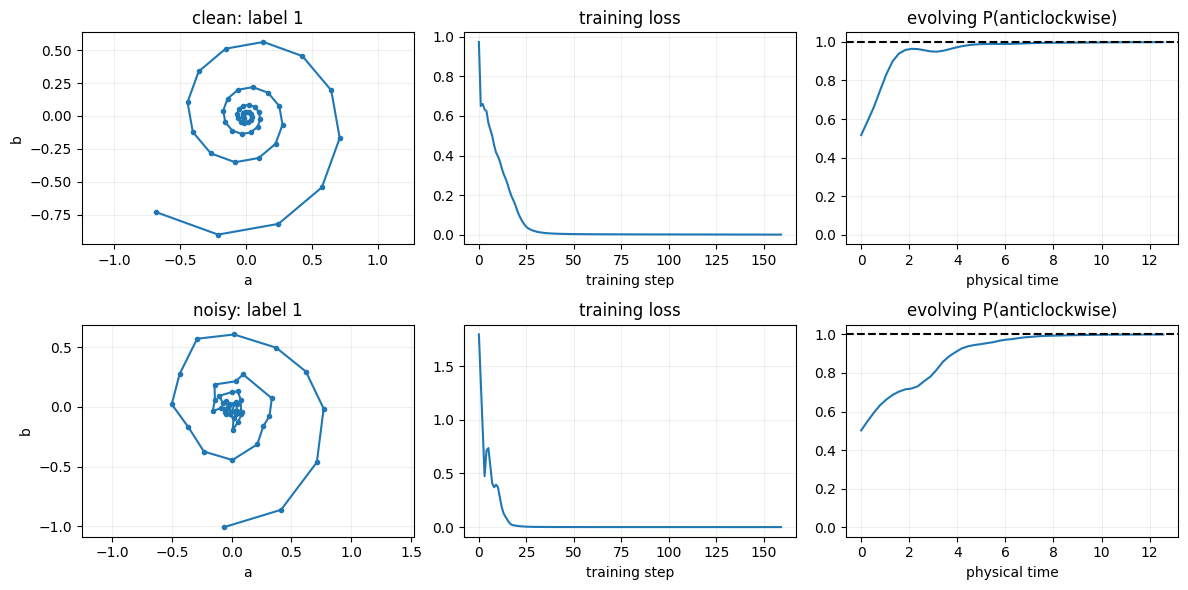

In [4]:
def spiral_data(seed: int, count: int = 64, points: int = 49,
                noise: float = 0.0, irregular: bool = False) -> tuple[jax.Array, jax.Array]:
    """Generate balanced labelled contracting spirals, optionally irregular/noisy."""
    rng = np.random.default_rng(seed)
    labels = np.arange(count) % 2
    rng.shuffle(labels)
    phases = rng.uniform(0, 2*np.pi, count)
    if irregular:
        grids = np.sort(rng.uniform(0, 4*np.pi, (count, points)), axis=1)
        grids[:, 0], grids[:, -1] = 0, 4*np.pi
    else:
        grids = np.broadcast_to(np.linspace(0, 4*np.pi, points), (count, points))
    angles = phases[:, None] + (4*labels[:, None]-2) * grids
    positions = np.stack([np.cos(angles), np.sin(angles)], axis=-1)
    positions *= np.exp(-0.3*grids)[..., None]
    positions += noise*rng.normal(size=positions.shape)
    controls = np.concatenate([grids[..., None], positions], axis=-1)
    return jnp.asarray(controls, dtype=jnp.float32), jnp.asarray(labels, dtype=jnp.float32)


def init_cde(key: jax.Array, channels: int = 3, hidden: int = 8) -> dict:
    """Initialize the starting-state, response and readout networks."""
    a, b, c = jr.split(key, 3)
    return {"init": init_mlp(a, channels, 16, hidden, scale=0.7),
            "field": init_mlp(b, hidden, 24, hidden*channels, scale=0.7),
            "readout": 0.2*jr.normal(c, (hidden,)), "bias": jnp.array(0.0)}


def cde_response(params: dict, y: jax.Array, channels: int) -> jax.Array:
    """Map memory to a bounded hidden-by-input response matrix."""
    return jnp.tanh(mlp(params["field"], y)).reshape(y.shape[0], channels)


def cde_scan(params: dict, control: jax.Array, substeps: int = 2) -> jax.Array:
    """Solve a piecewise-linear CDE with Heun updates; save at observation knots."""
    channels = control.shape[-1]
    y0 = jnp.tanh(mlp(params["init"], control[0]))

    def interval(y: jax.Array, delta: jax.Array) -> tuple[jax.Array, jax.Array]:
        dx = delta / substeps
        for _ in range(substeps):
            k1 = cde_response(params, y, channels) @ dx
            k2 = cde_response(params, y+k1, channels) @ dx
            y = y + 0.5*(k1+k2)
        return y, y

    _, saved = jax.lax.scan(interval, y0, jnp.diff(control, axis=0))
    return jnp.concatenate([y0[None, :], saved], axis=0)


def cde_logits(params: dict, controls: jax.Array) -> jax.Array:
    """Read one logit from each path's final hidden state."""
    return jax.vmap(lambda x: cde_scan(params, x)[-1] @ params["readout"]
                    + params["bias"])(controls)


def train_spirals(noise: float, seed: int) -> tuple[dict, np.ndarray, jax.Array, jax.Array]:
    """Fit and evaluate one small spiral classifier."""
    train_x, train_labels = spiral_data(seed, noise=noise)
    test_x, test_labels = spiral_data(seed+100, count=48, noise=noise)
    params = init_cde(jr.PRNGKey(seed))
    loss_fn = lambda p: jnp.mean(optax.sigmoid_binary_cross_entropy(
        cde_logits(p, train_x), train_labels))
    params, history = fit(params, loss_fn, steps=160, lr=0.01)
    logits = cde_logits(params, test_x)
    accuracy = float(jnp.mean((logits > 0) == test_labels))
    print(f"Noise {noise:.2f}: loss {history[0]:.3f} → {history[-1]:.3f}; test accuracy {accuracy:.1%}")
    assert np.isfinite(history).all() and history[-1] < history[0]
    return params, history, test_x, test_labels

clean_params, clean_history, clean_test, clean_labels = train_spirals(0.0, 31)
noisy_params, noisy_history, noisy_test, noisy_labels = train_spirals(0.04, 32)
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for row, (params, history, paths, labels, title) in enumerate([
    (clean_params, clean_history, clean_test, clean_labels, "clean"),
    (noisy_params, noisy_history, noisy_test, noisy_labels, "noisy"),
]):
    path = paths[0]
    states = cde_scan(params, path)
    probabilities = jax.nn.sigmoid(states @ params["readout"] + params["bias"])
    axes[row, 0].plot(path[:, 1], path[:, 2], ".-")
    axes[row, 0].set(title=f"{title}: label {int(labels[0])}", xlabel="a", ylabel="b")
    axes[row, 0].set_aspect("equal", adjustable="datalim")
    axes[row, 1].plot(history)
    axes[row, 1].set(title="training loss", xlabel="training step")
    axes[row, 2].plot(path[:, 0], probabilities)
    axes[row, 2].axhline(float(labels[0]), linestyle="--", color="black", label="true class")
    axes[row, 2].set(title="evolving P(anticlockwise)", xlabel="physical time", ylim=(-0.05, 1.05))
plt.tight_layout()
plt.show()

In [5]:
# Cross-check our transparent solver against Diffrax ControlTerm.
control = clean_test[0]
solver_knots = jnp.linspace(0, control.shape[0]-1, control.shape[0])
path = dfx.LinearInterpolation(solver_knots, control)
term = dfx.ControlTerm(lambda s, y, args: cde_response(clean_params, y, 3), path)
fine_knots = jnp.linspace(0, control.shape[0]-1, 2*(control.shape[0]-1)+1)
y0 = jnp.tanh(mlp(clean_params["init"], control[0]))
diffrax_states = dfx.diffeqsolve(
    term, dfx.Heun(), t0=solver_knots[0], t1=solver_knots[-1], dt0=None,
    y0=y0, stepsize_controller=dfx.StepTo(ts=fine_knots),
    saveat=dfx.SaveAt(ts=solver_knots), max_steps=1000,
).ys
solver_error = float(jnp.max(jnp.abs(diffrax_states-cde_scan(clean_params, control))))
print("Maximum scan vs Diffrax hidden-state difference:", solver_error)
assert solver_error < 2e-4

Maximum scan vs Diffrax hidden-state difference: 6.67572021484375e-06


**What to notice:** The model learns its initial state, response matrix and readout jointly. Only the final classification is trained; intermediate probabilities are diagnostic and need not improve monotonically. Noise does not change the equation. Perfect accuracy is not promised. The scan and Diffrax comparison checks that our recurrence really is the stated CDE discretization.

## 4. Irregular observations, missing measurements and counts (3.2.1)

First test the spiral classifier on independent, irregularly sampled spirals. Actual time is in the control even though the solver uses an index grid. This is a transfer test, not a claim that changing sampling leaves interpolation or accuracy unchanged.

Then construct a small partially observed dataset. A count increases only when its feature is observed. Rectilinear interpolation first advances time with old values, then updates the observed features and their counts at fixed real time. It does not look ahead to a future value. Fill-forward values are part of the representation, not claims about the true missing measurement.

Clean model on irregular samples: 100.0%
Columns: time, temperature, heart rate, temperature count, heart-rate count
[[ 0.  37.  80.   1.   1. ]
 [ 1.  37.  80.   1.   1. ]
 [ 1.  37.  85.   1.   2. ]
 [ 4.  37.  85.   1.   2. ]
 [ 4.  38.  85.   2.   2. ]
 [10.  38.  85.   2.   2. ]
 [10.  37.5 90.   3.   3. ]]


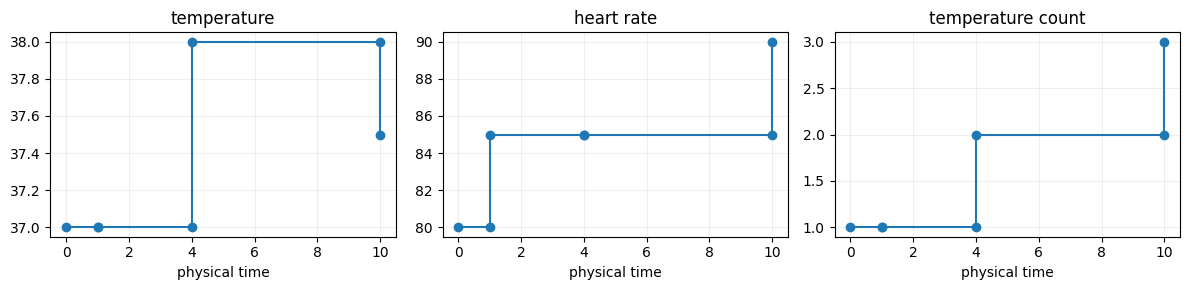

Final memory [latest temperature, temperature count, elapsed time]: [37.5  3.  10. ]


In [6]:
irregular_x, irregular_labels = spiral_data(133, count=48, noise=0.0, irregular=True)
irregular_accuracy = float(jnp.mean((cde_logits(clean_params, irregular_x)>0) == irregular_labels))
print("Clean model on irregular samples:", f"{irregular_accuracy:.1%}")


def rectilinear_control(times: np.ndarray, values: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Create time/value/count controls with causal fill-forward measurement updates."""
    observed = np.isfinite(values)
    counts = np.cumsum(observed, axis=0).astype(float)
    filled = np.zeros_like(values, dtype=float)
    previous = np.zeros(values.shape[1])
    for j in range(len(times)):
        previous = np.where(observed[j], values[j], previous)
        filled[j] = previous
    knots, points = [0.0], [np.r_[times[0], filled[0], counts[0]]]
    s = 0.0
    for j in range(1, len(times)):
        s += float(times[j]-times[j-1])
        knots.append(s)
        points.append(np.r_[times[j], filled[j-1], counts[j-1]])
        s += 1.0  # virtual solver time for a measurement update; real time stays fixed
        knots.append(s)
        points.append(np.r_[times[j], filled[j], counts[j]])
    return np.asarray(knots), np.asarray(points)

missing_times = np.array([0.0, 1.0, 4.0, 10.0])
missing_values = np.array([[37.0, 80.0], [np.nan, 85.0],
                           [38.0, np.nan], [37.5, 90.0]])
rect_s, rect_x = rectilinear_control(missing_times, missing_values)
print("Columns: time, temperature, heart rate, temperature count, heart-rate count")
print(rect_x)
assert np.array_equal(rect_x[[0, 2, 4, 6], 3:], [[1, 1], [1, 2], [2, 2], [3, 3]])
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, col, label in zip(axes, [1, 2, 3], ["temperature", "heart rate", "temperature count"]):
    ax.plot(rect_x[:, 0], rect_x[:, col], "o-")
    ax.set(xlabel="physical time", title=label)
plt.tight_layout()
plt.show()

# A hand-chosen CDE copies the temperature/count channels and integrates time.
# This shows that missing-data controls can be consumed by the SAME CDE update.
selector = np.zeros((3, 5))
selector[0, 1], selector[1, 3], selector[2, 0] = 1, 1, 1
memory0 = np.array([rect_x[0, 1], rect_x[0, 3], 0.0])
missing_memory = np.vstack([memory0, memory0 + np.cumsum(np.diff(rect_x, axis=0) @ selector.T, axis=0)])
print("Final memory [latest temperature, temperature count, elapsed time]:", missing_memory[-1])
assert np.allclose(missing_memory[-1], [37.5, 3.0, 10.0])

**What to notice:** When the heart rate is missing, its count does not increase. This distinguishes no new measurement from a new measurement equal to the old value. The vertical segments are continuous updates in the solver coordinate, taking place at fixed physical time. Different-length paths can be solved to their own endpoints; no shared timestamp grid is needed in the input representation.

## 5. RNNs and Example 3.14: a GRU is an Euler update

For an RNN $y_{j+1}=h_\theta(y_j,x_j)$, Euler with unit step applied to $y'=h_\theta(y,x)-y$ recovers the RNN exactly.

For the book's GRU,
$$h_{j+1}=n_j+i_j\odot(h_j-n_j),$$
and its continuous rule is
$$h'=(1-i)\odot(n-h).$$
Here $i$ retains old memory, $r$ gates the candidate calculation, and $n$ is the proposed new state. We explicitly implement the book's gate convention rather than relying on a library GRU's potentially different convention.

GRU vs unit Euler maximum error: 1.1102230246251565e-16


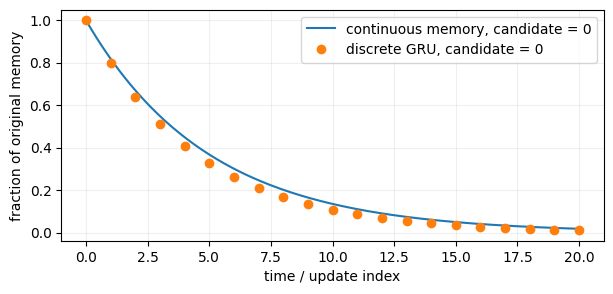

In [7]:
gru_rng = np.random.default_rng(51)
gru_weights = [gru_rng.normal(scale=0.3, size=shape)
               for shape in [(4, 2), (4, 4), (4, 2), (4, 4), (4, 2), (4, 4)]]
gru_biases = [gru_rng.normal(scale=0.1, size=4) for _ in range(4)]


def gru_gates(h: np.ndarray, x: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Calculate the book's retention gate and candidate memory."""
    w1, w2, w3, w4, w5, w6 = gru_weights
    b1, b2, b3, b4 = gru_biases
    sigmoid = lambda z: 1/(1+np.exp(-z))
    i = sigmoid(w1 @ x + w2 @ h + b1)
    r = sigmoid(w3 @ x + w4 @ h + b2)
    n = np.tanh(w5 @ x + b3 + r*(w6 @ h+b4))
    return i, n

h = gru_rng.normal(size=4)
x = np.array([0.4, -0.2])
i, n = gru_gates(h, x)
gru_update = n + i*(h-n)
euler_update = h + (1-i)*(n-h)
np.testing.assert_allclose(gru_update, euler_update, atol=1e-12)
print("GRU vs unit Euler maximum error:", np.max(np.abs(gru_update-euler_update)))

# A controlled gate/candidate example isolates the forgetting mechanism.
gate = 0.8
forget_times = np.linspace(0, 20, 201)
plt.plot(forget_times, np.exp(-(1-gate)*forget_times), label="continuous memory, candidate = 0")
plt.plot(np.arange(21), gate**np.arange(21), "o", label="discrete GRU, candidate = 0")
plt.xlabel("time / update index")
plt.ylabel("fraction of original memory")
plt.legend()
plt.show()

**What to notice:** The GRU/Euler equality is exact for a unit step and the same gates. The continuous solution and large-step discrete trajectory need not coincide. The forgetting plot holds the gate and candidate fixed to isolate exponential decay; it is not a claim that every trained GRU always forgets at a fixed rate.

## 6. Long sequences: a concrete second-order / log-ODE demonstration

**Teaching example for 3.2.3, not a full trained neural RDE.** Keep state $(a,b,I)$ with $da=dX_1$, $db=dX_2$, $dI=a\,dX_2$. Thus $I=\int a\,db$ is sensitive to the order of the two channels.

A block's total increment $(\Delta a,\Delta b)$ is insufficient. Add its second iterated integral
$$S^{12}=\sum_j(a_j-a_{\rm start})\Delta b_j+\tfrac12\sum_j\Delta a_j\Delta b_j.$$
Then the exact block update for this piecewise-linear toy is
$$I_{\rm new}=I_{\rm old}+a_{\rm start}\Delta b+S^{12}.$$
This is equivalent to the level-2 log-ODE update here: the signed-area term is $A^{12}=S^{12}-\tfrac12\Delta a\Delta b$. It preserves order information that coarse straight-line steps discard. Richer vector fields generally need higher levels or smaller blocks.

Same endpoint; right then up integral: 1.0
Same endpoint; up then right integral: 0.0
block size | blocks | first-level error | level-2 error
[[1.00000000e+01 1.20000000e+02 3.05435784e-01 1.06581410e-14]
 [5.00000000e+01 2.40000000e+01 6.84645545e+00 0.00000000e+00]
 [1.00000000e+02 1.20000000e+01 1.88464554e+01 3.55271368e-15]
 [2.00000000e+02 6.00000000e+00 1.88464554e+01 3.55271368e-15]]


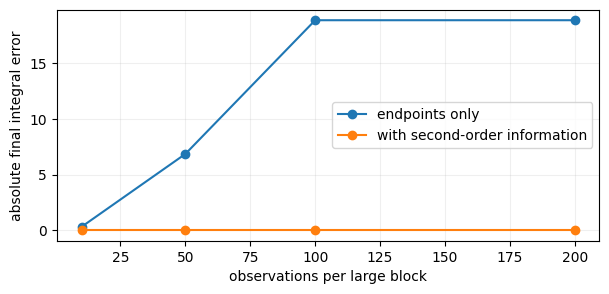

In [8]:
def integrate_order_path(points: np.ndarray) -> float:
    """Integrate a db exactly on piecewise-linear segments."""
    delta = np.diff(points, axis=0)
    return float(np.sum(points[:-1, 0]*delta[:, 1] + 0.5*delta[:, 0]*delta[:, 1]))

right_then_up = np.array([[0., 0.], [1., 0.], [1., 1.]])
up_then_right = np.array([[0., 0.], [0., 1.], [1., 1.]])
print("Same endpoint; right then up integral:", integrate_order_path(right_then_up))
print("Same endpoint; up then right integral:", integrate_order_path(up_then_right))

long_t = np.linspace(0, 12*np.pi, 1201)
long_path = np.column_stack([np.cos(long_t)-1, np.sin(long_t)])
reference_I = integrate_order_path(long_path)
coarse_results = []
for block in [10, 50, 100, 200]:
    edges = list(range(0, len(long_path)-1, block)) + [len(long_path)-1]
    coarse = integrate_order_path(long_path[edges])
    enriched = 0.0
    for start, end in zip(edges[:-1], edges[1:]):
        points = long_path[start:end+1]
        increment = points[-1]-points[0]
        relative = points-points[0]
        s12 = integrate_order_path(relative)
        enriched += points[0, 0]*increment[1]+s12
    assert abs(enriched-reference_I) < 1e-10
    coarse_results.append([block, len(edges)-1, abs(coarse-reference_I), abs(enriched-reference_I)])
print("block size | blocks | first-level error | level-2 error")
print(np.array(coarse_results))
plt.plot(np.array(coarse_results)[:, 0], np.array(coarse_results)[:, 2], "o-", label="endpoints only")
plt.plot(np.array(coarse_results)[:, 0], np.array(coarse_results)[:, 3], "o-", label="with second-order information")
plt.xlabel("observations per large block")
plt.ylabel("absolute final integral error")
plt.legend()
plt.show()

**What to notice:** Fewer blocks mean fewer sequential model updates. Computing summaries still reads the data, but they can be precomputed and reused during training. Exactness here is special to this small system; it does not imply that level-2 summaries preserve everything for every neural CDE.

## 7. Neural SDE generator + CDE discriminator (3.2.4)

**Small mechanism demonstration, not a reproduction of Chapter 4.** Generate Ornstein–Uhlenbeck paths with Euler–Maruyama:
$$dz=-0.8z\,dt+\sigma_\theta\,dW.$$
The unknown generator parameter is its noise scale. Real paths use $\sigma=0.55$; the generator starts at a different scale. This trainable coefficient is a minimal parameterized SDE, rather than a large drift/diffusion MLP.

A learned neural CDE reads $(t,z)$ and outputs a real/fake logit. Alternate discriminator and generator updates. Only the CDE's hidden-state trajectory is deterministic conditional on the generated path; the generator's paths are random. Use fresh noise each update and stop gradients through fake data for the discriminator update.

Generator sigma: initial 0.18; final 0.6316879987716675 ; real 0.55


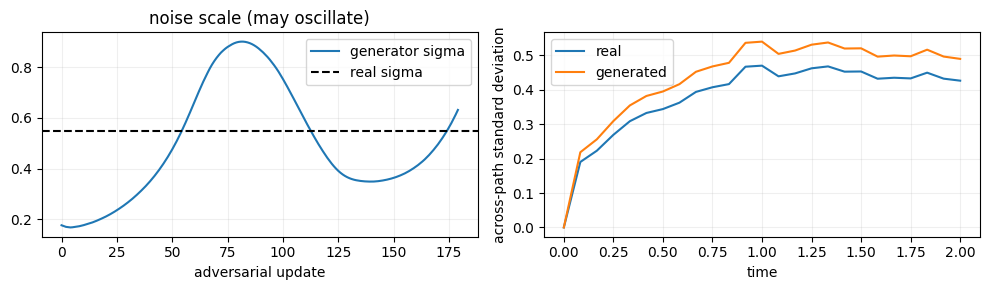

In [9]:
gan_times = jnp.linspace(0, 2, 25)
gan_dt = gan_times[1]-gan_times[0]
gan_true_sigma = 0.55


def ou_paths(sigma: jax.Array, noise: jax.Array) -> jax.Array:
    """Generate a batch of OU paths using fixed sampled Brownian increments."""
    def one(eps: jax.Array) -> jax.Array:
        def step(z: jax.Array, e: jax.Array) -> tuple[jax.Array, jax.Array]:
            z = z-0.8*z*gan_dt+sigma*jnp.sqrt(gan_dt)*e
            return z, z
        _, zs = jax.lax.scan(step, jnp.array(0.0), eps)
        values = jnp.concatenate([jnp.zeros(1), zs])
        return jnp.stack([gan_times, values], axis=-1)
    return jax.vmap(one)(noise)

gan_disc = init_cde(jr.PRNGKey(71), channels=2, hidden=6)
gan_generator = jnp.array(np.log(0.18), dtype=jnp.float32)
disc_opt, gen_opt = optax.adam(0.008), optax.adam(0.02)
disc_state, gen_state = disc_opt.init(gan_disc), gen_opt.init(gan_generator)


@jax.jit
def adversarial_step(d: dict, ds: Any, g: jax.Array, gs: Any,
                     key: jax.Array) -> tuple:
    """Take one discriminator update and one generator update."""
    kr, kf, kg = jr.split(key, 3)
    real = ou_paths(jnp.array(gan_true_sigma), jr.normal(kr, (32, 24)))
    fake = jax.lax.stop_gradient(ou_paths(jnp.exp(g), jr.normal(kf, (32, 24))))
    def d_loss(p: dict) -> jax.Array:
        return (jnp.mean(jax.nn.softplus(-cde_logits(p, real)))
                + jnp.mean(jax.nn.softplus(cde_logits(p, fake))))
    dl, dg = jax.value_and_grad(d_loss)(d)
    update, ds = disc_opt.update(dg, ds, d)
    d = optax.apply_updates(d, update)
    generator_noise = jr.normal(kg, (32, 24))
    def g_loss(log_sigma: jax.Array) -> jax.Array:
        generated = ou_paths(jnp.exp(log_sigma), generator_noise)
        return jnp.mean(jax.nn.softplus(-cde_logits(d, generated)))
    gl, gg = jax.value_and_grad(g_loss)(g)
    update, gs = gen_opt.update(gg, gs, g)
    g = optax.apply_updates(g, update)
    g = jnp.clip(g, -3.0, 0.7)  # keep this short demonstration in a stable range
    return d, ds, g, gs, dl, gl

gan_history = []
for step in range(180):
    gan_disc, disc_state, gan_generator, gen_state, dl, gl = adversarial_step(
        gan_disc, disc_state, gan_generator, gen_state, jr.PRNGKey(1000+step))
    gan_history.append([float(jnp.exp(gan_generator)), float(dl), float(gl)])
gan_history = np.asarray(gan_history)
assert np.isfinite(gan_history).all()
print("Generator sigma: initial 0.18; final", float(jnp.exp(gan_generator)), "; real", gan_true_sigma)
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(gan_history[:, 0], label="generator sigma")
axes[0].axhline(gan_true_sigma, color="black", linestyle="--", label="real sigma")
axes[0].set(xlabel="adversarial update", title="noise scale (may oscillate)")
axes[0].legend()
heldout_noise = jr.normal(jr.PRNGKey(999), (100, 24))
for scale, name in [(gan_true_sigma, "real"), (float(jnp.exp(gan_generator)), "generated")]:
    samples = ou_paths(jnp.array(scale), heldout_noise)
    axes[1].plot(gan_times, jnp.std(samples[:, :, 1], axis=0), label=name)
axes[1].set(xlabel="time", ylabel="across-path standard deviation")
axes[1].legend()
plt.tight_layout()
plt.show()

**What to notice:** The generator learns through the discriminator's response to entire paths. GAN losses are not supervised regression losses and may oscillate; a short run need not identify the true noise scale. The held-out path variability plot is a separate diagnostic. This example illustrates the training connection, not reliable SDE parameter estimation.

## 8. Universal approximation intuition: nonlinear hidden features, linear readout (3.3.1)

**Demonstration, not a proof.** Construct a CDE whose hidden features are
$$y=(x,\ \int x\,dt,\ x^2),\qquad f(y)=\begin{bmatrix}0&1\\y_1&0\\0&2y_1\end{bmatrix}.$$
The third row uses $d(x^2)=2x\,dx$. A linear readout can then learn a target such as $0.7\int xdt+0.3x(T)^2+0.2$.

The theorem says a sufficiently rich neural CDE can produce enough features to approximate continuous functions of sequences under its assumptions. This finite feature construction illustrates why a simple final readout is not a limitation; it cannot establish universal approximation.

Readout [x, integral, x², bias]: [1.03926992e-10 7.00000000e-01 3.00000000e-01 2.00000000e-01]
Held-out maximum error: 1.3667689202634392e-09


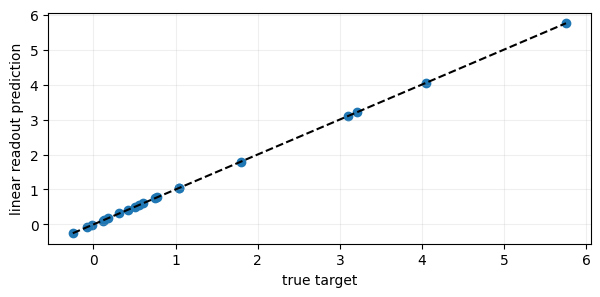

In [10]:
feature_rng = np.random.default_rng(81)
feature_times = np.linspace(0, 1, 101)
feature_states, feature_targets = [], []
for _ in range(60):
    a, b, c = feature_rng.normal(size=3)
    signal = lambda t: a+b*t+c*np.sin(2*np.pi*t)
    slope = lambda t: b+2*np.pi*c*np.cos(2*np.pi*t)
    response = lambda y: np.array([[0., 1.], [y[0], 0.], [0., 2*y[0]]])
    state = analytic_cde(lambda t: np.array([1., slope(t)]), response,
                         np.array([a, 0., a*a]), feature_times)[-1]
    feature_states.append(state)
    exact_integral, endpoint = a+0.5*b, a+b
    feature_targets.append(0.7*exact_integral+0.3*endpoint**2+0.2)
features = np.asarray(feature_states)
targets = np.asarray(feature_targets)
design = np.column_stack([features, np.ones(len(features))])
weights = np.linalg.lstsq(design[:40], targets[:40], rcond=None)[0]
heldout_prediction = design[40:] @ weights
print("Readout [x, integral, x², bias]:", weights)
print("Held-out maximum error:", np.max(np.abs(heldout_prediction-targets[40:])))
assert np.max(np.abs(heldout_prediction-targets[40:])) < 1e-6
plt.scatter(targets[40:], heldout_prediction)
plt.plot([targets[40:].min(), targets[40:].max()], [targets[40:].min(), targets[40:].max()], "k--")
plt.xlabel("true target")
plt.ylabel("linear readout prediction")
plt.show()

## 9. Copying paths versus an ODE that only sees current values (3.3.2)

A CDE with $f=I$ and $y(0)=X(0)$ copies the input: $dy=dX$ implies $y=X$.

An alternative $y'=h(y,X)$ cannot copy **every** possible path exactly: two inputs can pass through the same $(y,X)$ at the same time but have different slopes. The function $h$ would have to return two different velocities for identical arguments.

We illustrate this with $x_1(t)=t$ and $x_2(t)=2t$ at $t=0$. An input-value tracking ODE $y'=k(x-y)$ is a useful practical alternative, but it lags rather than copies exactly.

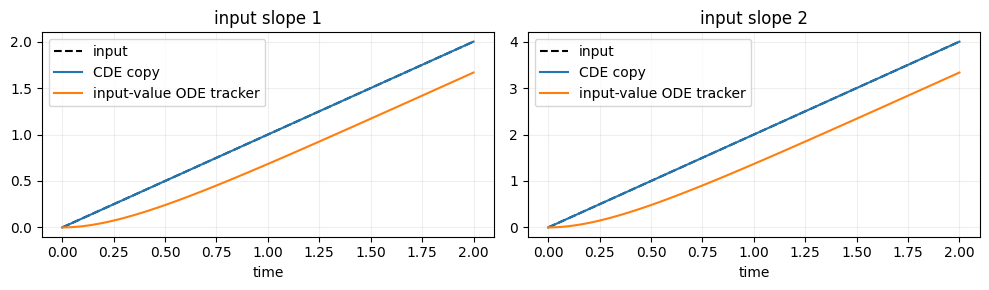

At t=0 both paths have x=y=0, but exact copying requires velocities 1 and 2.


In [11]:
copy_grid = np.linspace(0, 2, 101)
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, slope in zip(axes, [1.0, 2.0]):
    x = slope*copy_grid
    copied = np.r_[x[0], x[0]+np.cumsum(np.diff(x))]
    tracker = solve_ivp(lambda t, y: 3*(slope*t-y), (0, 2), [0.0], t_eval=copy_grid,
                        rtol=1e-8, atol=1e-10).y[0]
    np.testing.assert_allclose(copied, x, atol=1e-12)
    ax.plot(copy_grid, x, "k--", label="input")
    ax.plot(copy_grid, copied, label="CDE copy")
    ax.plot(copy_grid, tracker, label="input-value ODE tracker")
    ax.set(title=f"input slope {slope:g}", xlabel="time")
    ax.legend()
plt.tight_layout()
plt.show()
print("At t=0 both paths have x=y=0, but exact copying requires velocities 1 and 2.")

**What to notice:** The slope argument establishes the limitation for the stated alternative model class. The tracking plot is one illustrative alternative, not an empirical comparison against every possible ODE. A CDE can represent input-value ODEs by augmenting its state to store the input and adding time to the control.

## 10. Translation and reparameterisation invariance (3.3.3)

**Translation:** $X$ and $X+c$ have identical increments. If initialization is fixed, their states coincide. Initializing from $X(0)$ allows the starting level to matter.

**Reparameterisation:** traversing the same geometric path at a different speed preserves the exact final state. Appending actual time changes the path geometry when real timing changes. Do not confuse changing the solver coordinate with changing the recorded timestamps.

In [12]:
base = np.array([1.0, 2.0, 1.5, 3.0])
shifted = base+100
fixed_initial_states = [np.r_[0., np.cumsum(np.diff(x))] for x in [base, shifted]]
input_initial_states = [np.r_[x[0], x[0]+np.cumsum(np.diff(x))] for x in [base, shifted]]
assert np.allclose(*fixed_initial_states)
print("Fixed initialization final states:", [x[-1] for x in fixed_initial_states])
print("Input-dependent initialization final states:", [x[-1] for x in input_initial_states])

# For dy = y dx, y(0)=1, the endpoint depends on total x increment, not speed.
for duration in [1., 10.]:
    grid = np.linspace(0, duration, 101)
    out = analytic_cde(lambda t: np.array([1/duration]), lambda y: np.array([[y[0]]]),
                       np.array([1.]), grid)
    assert abs(out[-1, 0]-np.e) < 1e-7
    print(f"Same signal excursion over {duration:g} time units: final state {out[-1, 0]:.6f}")

# Add real time and accumulate the signal: integral differs when actual duration differs.
for duration in [1., 10.]:
    grid = np.linspace(0, duration, 101)
    out = analytic_cde(lambda t: np.array([1., 1/duration]), signal_response,
                       np.array([0., 0.]), grid)
    print(f"With time channel, duration {duration:g}: integral {out[-1, 1]:.3f}")
    assert abs(out[-1, 1]-duration/2) < 1e-7

Fixed initialization final states: [np.float64(2.0), np.float64(2.0)]
Input-dependent initialization final states: [np.float64(3.0), np.float64(103.0)]
Same signal excursion over 1 time units: final state 2.718282
Same signal excursion over 10 time units: final state 2.718282
With time channel, duration 1: integral 0.500
With time channel, duration 10: integral 5.000


## 11. Bounded responses, gates and matrix cost (3.4.1–3.4.2)

A final $\tanh$ bounds each response coefficient; a sigmoid gate can reduce it further. This limits sensitivity to input increments, not the entire hidden state or its velocity independently of $X'$.

If the input has $d_x$ channels, the memory has $d_y$ components and the last internal layer has width $d_h$, the dense output layer needs $(d_h+1)d_yd_x$ parameters, including biases. This may dominate cost.

The book's sparse-matrix and rank-one observations are anecdotal. We demonstrate their mathematical difference, not a benchmark claim about which is best.

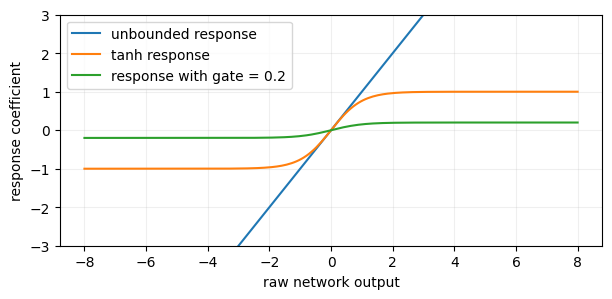

channels=3, memory=8, internal width=24: 600 output-layer parameters
channels=20, memory=64, internal width=128: 165,120 output-layer parameters
channels=100, memory=128, internal width=256: 3,289,600 output-layer parameters
Matrix ranks [dense, sparse, rank-one]: [np.int64(6), np.int64(6), np.int64(1)]


In [13]:
response_inputs = np.linspace(-8, 8, 201)
plt.plot(response_inputs, response_inputs, label="unbounded response")
plt.plot(response_inputs, np.tanh(response_inputs), label="tanh response")
plt.plot(response_inputs, 0.2*np.tanh(response_inputs), label="response with gate = 0.2")
plt.ylim(-3, 3)
plt.xlabel("raw network output")
plt.ylabel("response coefficient")
plt.legend()
plt.show()

for dx, dy, width in [(3, 8, 24), (20, 64, 128), (100, 128, 256)]:
    dense_count = (width+1)*dy*dx
    print(f"channels={dx}, memory={dy}, internal width={width}: {dense_count:,} output-layer parameters")

matrix_rng = np.random.default_rng(111)
dense_matrix = matrix_rng.normal(size=(8, 6))
sparse_matrix = dense_matrix*(matrix_rng.random((8, 6))<0.4)
rank_one = np.outer(matrix_rng.normal(size=8), matrix_rng.normal(size=6))
print("Matrix ranks [dense, sparse, rank-one]:",
      [np.linalg.matrix_rank(m) for m in [dense_matrix, sparse_matrix, rank_one]])

**What to notice:** Sparse matrices may still represent several independent response directions. A rank-one matrix sends every input change into a single response direction at a given state, although that direction can change with the state. Parameter count and actual speed are different: zeros only save execution time if the implementation takes advantage of sparsity.

## 12. Stacked CDEs (3.4.3)

Let layer 1 copy $x$: $dy_1=dx$. Let layer 2 integrate layer 1 against its own increments: $dy_2=y_1\,dy_1$.

Substitution gives a single joint CDE:
$$d\begin{bmatrix}y_1\\y_2\end{bmatrix}=\begin{bmatrix}1\\y_1\end{bmatrix}dx.$$
For $x(0)=0$, the exact answer is $y_1=x$ and $y_2=x^2/2$. This is a small transparent example of stacking; a neural version replaces these chosen response functions with trainable networks.

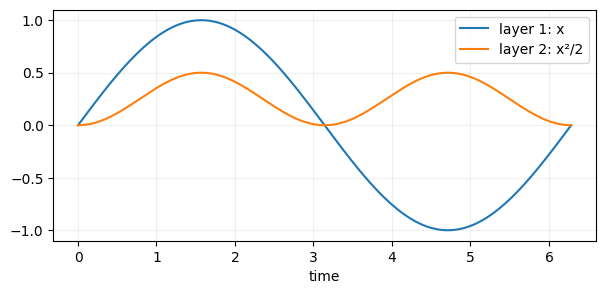

In [14]:
stack_grid = np.linspace(0, 2*np.pi, 151)
stacked = analytic_cde(lambda t: np.array([np.cos(t)]),
                       lambda y: np.array([[1.], [y[0]]]),
                       np.array([0., 0.]), stack_grid)
stack_truth = np.column_stack([np.sin(stack_grid), 0.5*np.sin(stack_grid)**2])
assert np.max(np.abs(stacked-stack_truth)) < 1e-7
plt.plot(stack_grid, stacked[:, 0], label="layer 1: x")
plt.plot(stack_grid, stacked[:, 1], label="layer 2: x²/2")
plt.xlabel("time")
plt.legend()
plt.show()

## 13. Four interpolation schemes and future-information checks (3.5)

Connect the same observations with:

1. **Backward Hermite:** cubic segments, matching first derivatives, with backward-difference slopes. Good for adaptive solvers when predictions at fully observed observation times suffice.
2. **Linear:** straight segments. Cheap, but slope jumps occur at knots.
3. **Rectilinear:** advance real time, then update values at fixed real time. Supports causal predictions and partially observed streams.
4. **Natural cubic:** very smooth, but fitting the whole curve can let far-future observations change earlier segments.

We use the next interval's secant slope at the first point when no preceding point exists, as Diffrax does by default. Each channel is handled separately. With missing observations, ordinary splines can bridge to a later observed value, so they must not be used for online predictions that would reveal that future value.

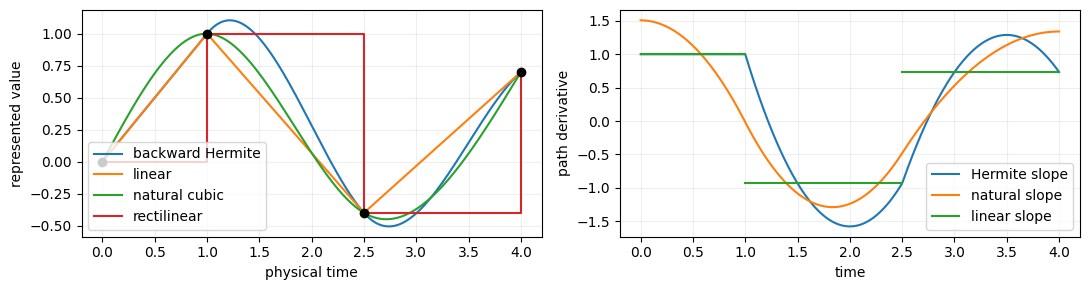

SciPy / Diffrax backward-Hermite agreement checked.


In [15]:
interp_t = np.array([0., 1., 2.5, 4.])
interp_v = np.array([0., 1., -0.4, 0.7])
secants = np.diff(interp_v)/np.diff(interp_t)
backward_slopes = np.r_[secants[0], secants]
hermite = CubicHermiteSpline(interp_t, interp_v, backward_slopes)
natural = CubicSpline(interp_t, interp_v, bc_type="natural")
interp_dense = np.linspace(0, 4, 301)
rect_knots, rect_points = rectilinear_control(interp_t, interp_v[:, None])
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].plot(interp_dense, hermite(interp_dense), label="backward Hermite")
axes[0].plot(interp_dense, np.interp(interp_dense, interp_t, interp_v), label="linear")
axes[0].plot(interp_dense, natural(interp_dense), label="natural cubic")
axes[0].plot(rect_points[:, 0], rect_points[:, 1], label="rectilinear")
axes[0].scatter(interp_t, interp_v, color="black", zorder=5)
axes[0].set(xlabel="physical time", ylabel="represented value")
axes[0].legend()
axes[1].plot(interp_dense, hermite(interp_dense, 1), label="Hermite slope")
axes[1].plot(interp_dense, natural(interp_dense, 1), label="natural slope")
for j in range(len(secants)):
    axes[1].plot(interp_t[j:j+2], [secants[j], secants[j]], color="C2",
                 label="linear slope" if j == 0 else None)
axes[1].set(xlabel="time", ylabel="path derivative")
axes[1].legend()
plt.tight_layout()
plt.show()

# Verify our SciPy backward-Hermite construction against Diffrax.
dfx_coeffs = dfx.backward_hermite_coefficients(jnp.asarray(interp_t), jnp.asarray(interp_v))
dfx_hermite = dfx.CubicInterpolation(jnp.asarray(interp_t), dfx_coeffs)
dfx_values = jax.vmap(dfx_hermite.evaluate)(jnp.asarray(interp_dense))
np.testing.assert_allclose(dfx_values, hermite(interp_dense), atol=1e-5)
print("SciPy / Diffrax backward-Hermite agreement checked.")

In [16]:
# Change a far-future observation; inspect the first interval.
changed_v = interp_v.copy()
changed_v[-1] += 4.0
changed_secants = np.diff(changed_v)/np.diff(interp_t)
changed_hermite = CubicHermiteSpline(interp_t, changed_v,
                                    np.r_[changed_secants[0], changed_secants])
changed_natural = CubicSpline(interp_t, changed_v, bc_type="natural")
early = np.linspace(0.1, 0.9, 20)
hermite_future_effect = np.max(np.abs(changed_hermite(early)-hermite(early)))
natural_future_effect = np.max(np.abs(changed_natural(early)-natural(early)))
print("Changing t=4 observation; maximum effect before t=1:")
print("Backward Hermite:", hermite_future_effect)
print("Natural cubic:", natural_future_effect)
assert hermite_future_effect < 1e-12 and natural_future_effect > 1e-3

# But linear and Hermite still need the NEXT observation inside the first interval.
changed_next = interp_v.copy()
changed_next[1] += 2
print("At t=0.5, linear value before/after changing the t=1 observation:",
      np.interp(0.5, interp_t, interp_v), np.interp(0.5, interp_t, changed_next))
print("Rectilinear value at physical t=0.5 stays at the known value 0.")

# Numerical effect: same x:0→1 path, different numbers of Euler steps.
# dy=y dx, y0=1 has exact endpoint e.
print("Euler steps | endpoint | error against exp(1)")
for steps in [1, 2, 10, 100]:
    endpoint = (1+1/steps)**steps
    print(steps, round(endpoint, 6), round(abs(endpoint-np.e), 6))

Changing t=4 observation; maximum effect before t=1:
Backward Hermite: 0.0
Natural cubic: 0.055431230618284255
At t=0.5, linear value before/after changing the t=1 observation: 0.5 1.5
Rectilinear value at physical t=0.5 stays at the known value 0.
Euler steps | endpoint | error against exp(1)
1 2.0 0.718282
2 2.25 0.468282
10 2.593742 0.124539
100 2.704814 0.013468


**What to notice:** Smoothness and causal availability are separate properties. Natural splines are smooth but can use distant future data. Hermite is smooth and local but still needs the next observation to build an interval. Rectilinear updates remain possible without future measurements. Linear/rectilinear controls have derivative jumps: an adaptive ODE solver should be told the knot locations, or integration should be split at those knots. Our learned CDE solver explicitly steps within every segment.

**One-page recap**

- **CDE:** input increments drive updates to an evolving memory.
- **Time:** lets the model detect duration and timing, even for constant measurements.
- **Initialization:** preserves the starting input level, which increments alone cannot reveal.
- **Spirals:** train the initial-value, response and readout networks from sequence labels.
- **Irregular/missing data:** represent actual time, observed values and counts; choose interpolation consistent with prediction availability.
- **RNN/GRU:** recover discrete recurrent updates with Euler steps of a continuous system.
- **Long sequences:** large blocks need higher-order summaries to preserve within-block order.
- **SDE training:** a neural CDE can discriminate generated versus real paths.
- **Readout:** simple linear output can be expressive when the hidden path features are rich.
- **Architecture:** bounded/gated response matrices aid stability; matrix size and stacking cost computation.
- **Interpolation:** backward Hermite when its information requirements suffice; rectilinear for stricter online/missing-data requirements.

**Source and limits:** Kidger, _On Neural Differential Equations_, Chapter 3, especially Examples 3.2, 3.8, 3.14; Appendix D.3 specifies the full spiral experiment. The source PDF is the project file `ordinary neural equations.pdf`. Toy constructions illustrate mechanisms; they do not prove universal approximation, reproduce all published benchmarks, or establish that a solver/training choice is optimal.